# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

In [3]:
data_raw = pd.read_csv('data/cash_app_report_1781988897511.csv')
data_raw.head(25)

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-06-20 16:54:15 EDT,NaN,Bitcoin Sell,USD,$10.00,-$0.20,$9.80,BTC,"$63,371.65",0.000158,COMPLETE,sale of BTC 0.00015780,NaN,Cash Balance
1,2026-06-20 08:23:07 EDT,NaN,Deposits,USD,$100.00,$0.00,$100.00,NaN,NaN,NaN,COMPLETE,Add Cash,NaN,Visa debit 3333
2,2026-06-20 08:22:51 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VFH,$131.44,0.076080,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Vanguard Financials ETF,NaN,Cash Balance
3,2026-06-20 08:22:38 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$232.97,0.042920,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Dick's Sporting Goods,NaN,Cash Balance
4,2026-06-20 08:22:21 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DAL,$84.16,0.118820,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Delta Air Lines,NaN,Cash Balance
5,2026-06-20 08:22:07 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,M,$24.14,0.414250,WAITING_ON_EXTERNAL,Scheduled $10 Purchase of Macy's,NaN,Cash Balance
6,2026-06-20 08:21:39 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,MRNA,$64.06,0.078050,WAITING_ON_EXTERNAL,Scheduled $5 Sale of Moderna,NaN,Cash Balance
7,2026-06-20 08:21:25 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$310.72,0.032180,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Marvell Technology,NaN,Cash Balance
8,2026-06-20 08:21:10 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.76,0.133760,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Block,NaN,Cash Balance
9,2026-06-20 08:20:54 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.21,0.121640,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Wells Fargo,NaN,Cash Balance


In [4]:
data_raw[data_raw['Transaction Type'].isna()]

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
3,2026-06-20 08:22:38 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DKS,$232.97,0.04292,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Dick's Sporting Goods,NaN,Cash Balance
4,2026-06-20 08:22:21 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,DAL,$84.16,0.11882,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Delta Air Lines,NaN,Cash Balance
6,2026-06-20 08:21:39 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,MRNA,$64.06,0.07805,WAITING_ON_EXTERNAL,Scheduled $5 Sale of Moderna,NaN,Cash Balance
7,2026-06-20 08:21:25 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,MRVL,$310.72,0.03218,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Marvell Technology,NaN,Cash Balance
8,2026-06-20 08:21:10 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,XYZ,$74.76,0.13376,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Block,NaN,Cash Balance
9,2026-06-20 08:20:54 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,WFC,$82.21,0.12164,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Wells Fargo,NaN,Cash Balance
10,2026-06-20 08:20:38 EDT,NaN,NaN,USD,$5.00,$0.00,$5.00,AMAT,$616.70,0.00811,WAITING_ON_EXTERNAL,Scheduled $5 Sale of Applied Materials,NaN,Cash Balance
11,2026-06-20 08:20:24 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HOOD,$108.17,0.09245,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Robinhood Markets,NaN,Cash Balance
12,2026-06-20 08:20:10 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,JPM,$325.23,0.03075,WAITING_ON_EXTERNAL,Scheduled $10 Sale of JPMorgan Chase,NaN,Cash Balance
13,2026-06-20 08:19:50 EDT,NaN,NaN,USD,$10.00,$0.00,$10.00,HIMS,$35.44,0.28217,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Hims & Hers Health,NaN,Cash Balance


In [5]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.000158
1           NaN
2      0.076080
3      0.042920
4      0.118820
         ...   
553         NaN
554         NaN
555         NaN
556         NaN
557         NaN
Name: Asset Amount, Length: 558, dtype: float64

In [6]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type'].fillna('Stock Sell')
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data.sample(10, random_state=0xCAFE)

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
125,2026-06-15 13:30:03+00:00,-5.00,-5.00,490.50,0.01019,0.0,MA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Mastercard,NaN
197,2026-06-03 19:53:34+00:00,-10.00,-10.00,382.58,0.02613,0.0,MSGS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Madison Square Garden,NaN
487,2026-05-29 14:29:28+00:00,-25.00,-25.00,125.99,0.19843,0.0,TGT,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Target,NaN
445,2026-06-01 13:30:06+00:00,-25.00,-25.00,34.43,0.72611,0.0,PZZA,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Papa John's,NaN
153,2026-06-08 16:30:32+00:00,-10.00,-10.00,82.12,0.12177,0.0,NFLX,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Netflix,NaN
32,2026-06-18 16:29:52+00:00,0.04,0.04,NaN,0.00000,0.0,GM,Stock Dividends,USD,NaN,Cash Balance,COMPLETE,$0.04 Dividend from General Motors,NaN
305,2026-06-03 13:33:11+00:00,-10.00,-10.00,16.14,0.61957,0.0,F,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Ford Motor,NaN
170,2026-06-04 13:30:18+00:00,-5.00,-5.00,72.92,0.06856,0.0,UBER,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Uber Technologies,NaN
306,2026-06-03 13:33:00+00:00,-10.00,-10.00,212.67,0.04702,0.0,MS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Morgan Stanley,NaN
293,2026-06-03 13:54:31+00:00,-10.00,-10.00,45.68,0.21892,0.0,BAM,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Brookfield Asset Management,NaN


In [7]:
p2p_data = (data[data['trans_type'] == 'P2P']
 [['date', 'amount', 'currency', 'trans_id', 'account', 'status', 'notes', 'name_trans']]
    .assign(date=lambda x: x['date'].dt.date)
)
p2p_data

,date,amount,currency,trans_id,account,status,notes,name_trans
551,2026-01-25,-400.0,USD,#D-824GXRGG,WELLS FARGO BANK,COMPLETE,genny,Zephaniah Anderson
552,2025-09-19,-105.0,USD,#D-25XJ478O,WELLS FARGO BANK,COMPLETE,bull,Ana
553,2025-09-16,70.0,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
555,2022-11-28,-20.0,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
556,2022-10-07,-10.0,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves
557,2021-08-04,-15.0,USD,b1aawxk,Wells Fargo Bank,COMPLETE,lieberman baby gift,Mark Brown


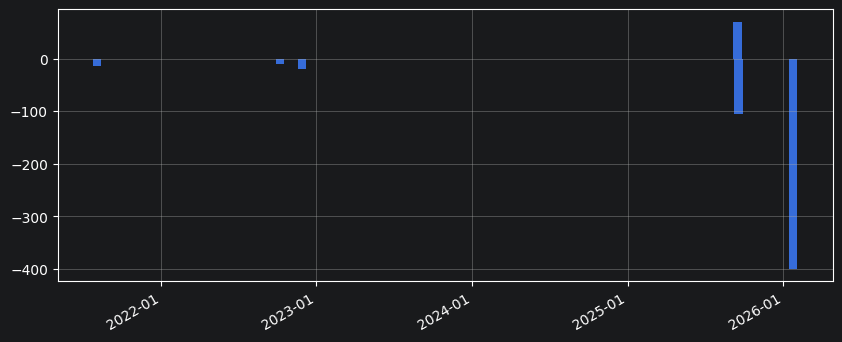

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    p2p_data['date'],
    p2p_data['amount'],
    width=20,  # width in days
)

ax.grid(True)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()

In [7]:
data.describe()

,net_amount,amount,asset_price,asset_amount,fee
count,558.000000,558.000000,467.000000,558.000000,555.000000
mean,0.259516,0.270161,4265.262762,0.127202,-0.010703
std,40.624571,40.622071,16529.641906,0.238348,0.057115
min,-400.000000,-400.000000,5.130000,0.000000,-0.500000
25%,-10.000000,-10.000000,57.680000,0.012765,0.000000
50%,-10.000000,-10.000000,131.730000,0.046530,0.000000
75%,-5.000000,-5.000000,301.315000,0.127965,0.000000
max,200.000000,200.000000,80346.140000,2.378910,0.000000


In [8]:
data.nunique().sort_values(ascending=False)

asset_price     461
asset_amount    459
date            446
notes           331
asset_type      163
amount           42
net_amount       41
trans_type       10
trans_id          7
fee               6
account           5
name_trans        5
status            3
currency          1
dtype: int64

In [9]:
data['asset_type'].value_counts()

asset_type
BTC     27
XYZ     12
JPM     12
WFC     10
ORCL    10
        ..
CBRS     1
AVGO     1
VBR      1
TSM      1
NVDA     1
Name: count, Length: 163, dtype: int64

In [10]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 .head(25)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,27,-172.26,"(-24.5, -9.8, -4.9, -0.98, 5.0, 10.0, 20.0)",7
JPM,12,-70.00,"(-25.0, -10.0, -5.0, 10.0, 20.0)",5
XYZ,12,-161.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0, 10.0)",7
ORCL,10,-85.00,"(-10.0, -5.0)",2
WFC,10,-71.00,"(-25.0, -10.0, -5.0, -1.0, 10.0)",5
AMZN,9,-151.00,"(-50.0, -25.0, -10.0, -1.0)",4
META,9,-71.00,"(-10.0, -5.0, -1.0)",3
MCD,9,-89.80,"(-25.0, -10.0, -5.0, 0.2)",4
PZZA,9,-75.00,"(-25.0, -10.0, -5.0, 10.0)",4


In [11]:
data['currency'].value_counts()

currency
USD    558
Name: count, dtype: int64

In [12]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    409
Deposits                      62
Stock Sell                    31
Bitcoin Buy                   22
Savings Internal Transfer     12
Stock Dividends                7
P2P                            6
Bitcoin Sell                   5
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [13]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count',
                 values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(40)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,Stock Sell,total
asset_type,,,,,,
total,22,5,409,7,31,474
BTC,22,5,0,0,0,27
XYZ,0,0,11,0,1,12
JPM,0,0,10,0,2,12
ORCL,0,0,10,0,0,10
WFC,0,0,9,0,1,10
META,0,0,9,0,0,9
MCD,0,0,8,1,0,9
PZZA,0,0,8,0,1,9


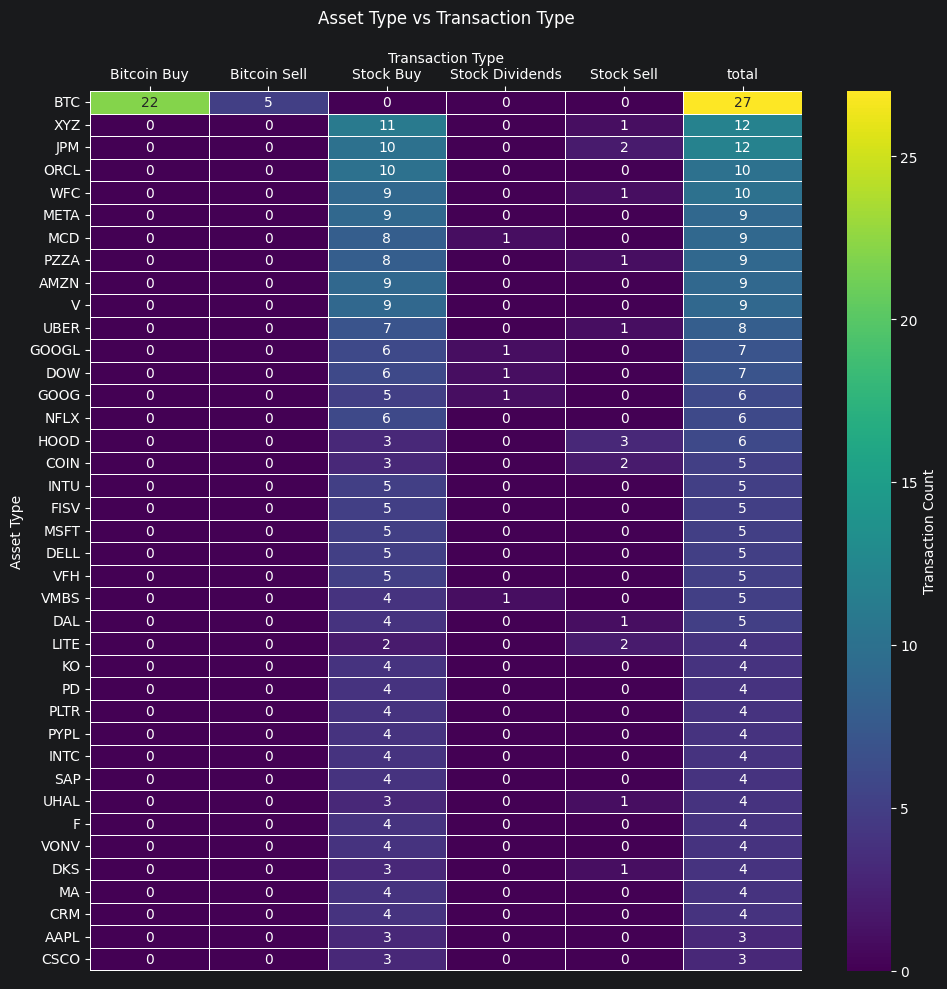

In [14]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,
)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [15]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
0,2026-06-20 20:54:15+00:00,9.8,10.00,63371.65,0.000158,-0.20,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00015780,NaN
15,2026-06-20 11:51:40+00:00,-5.0,-4.90,64191.63,0.000076,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007633,NaN
24,2026-06-18 17:13:37+00:00,19.6,20.00,61888.37,0.000323,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00032316,NaN
106,2026-06-16 12:39:28+00:00,4.9,5.00,66069.72,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007568,NaN
107,2026-06-16 12:03:53+00:00,4.9,5.00,65883.50,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007589,NaN
110,2026-06-16 01:27:11+00:00,-5.0,-4.90,66797.17,0.000073,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
146,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
226,2026-06-03 19:29:17+00:00,-10.0,-9.80,66010.01,0.000148,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014846,NaN
253,2026-06-03 16:16:50+00:00,-10.0,-9.80,66582.56,0.000147,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014719,NaN
277,2026-06-03 15:14:44+00:00,-1.0,-0.98,66904.02,0.000015,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001465,NaN


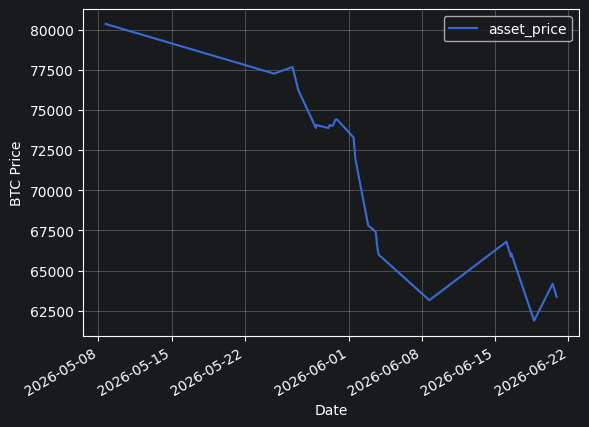

In [16]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')
plt.grid()

In [17]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     22
Bitcoin Sell     5
Name: count, dtype: int64

In [18]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-237.0
Bitcoin Sell,58.8


In [19]:
data_btc['net_amount'].sum()

np.float64(-178.2)

In [20]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003176
Bitcoin Sell    0.000949
Name: asset_amount, dtype: float64

In [21]:
data_btc['asset_amount'].sum()

np.float64(0.00412535)

In [22]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00222699)

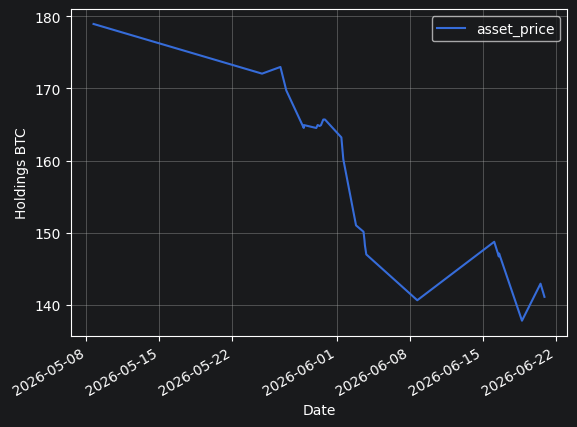

In [23]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')
plt.grid()

In [24]:
data_btc['asset_price'] * data_btc['asset_amount']

0      10.000046
15      4.899747
24     19.999846
106     5.000156
107     4.999899
110     4.900240
146    19.999798
226     9.799846
253     9.800287
277     0.980144
374     9.800221
385     0.979969
402     9.799652
460     4.900136
462     9.799865
465     4.900112
466     9.799903
470     9.799965
474    24.500200
481    24.499951
485    24.500084
504     9.799731
508     9.800031
531    24.499991
548     9.799898
549     4.900356
550     9.799819
dtype: float64

In [25]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
8,2026-06-20 12:21:10+00:00,10.0,10.0,74.76,0.13376,0.0,XYZ,Stock Sell,USD,NaN,Cash Balance,WAITING_ON_EXTERNAL,Scheduled $10 Sale of Block,NaN
68,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
113,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
161,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
237,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
249,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
262,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
300,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
303,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
406,2026-06-01 13:30:51+00:00,-25.0,-25.0,77.50,0.32258,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Block,NaN


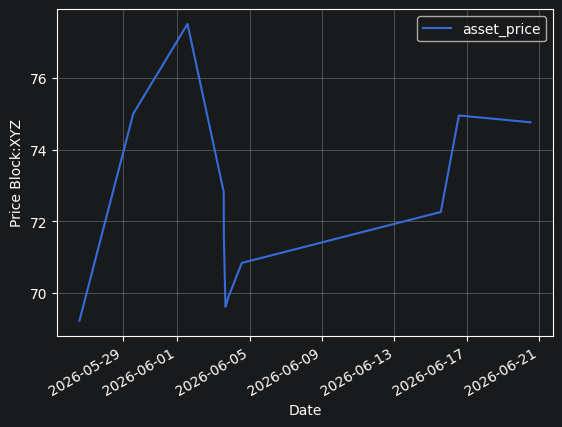

In [26]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')
plt.grid()

In [27]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     27
JPM     12
XYZ     12
ORCL    10
WFC     10
        ..
UNFI     1
UNH      1
DASH     1
CXSE     1
ZG       1
Name: amount, Length: 163, dtype: int64

In [28]:
asset_price = data.pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_price').bfill(axis=0)
asset_price.head()

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-24 19:57:02+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:06:39+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-26 14:09:07+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,69.23,149.54,42.9,36.36,36.25
2026-05-27 03:38:54+00:00,307.3,133.22,183.16,270.0,223.99,65.83,18.43,41.48,445.96,543.37,...,152.01,77.41,30.62,118.97,51.35,75.00,149.54,42.9,36.36,36.25


In [29]:
data['asset_amount'].describe()

count    558.000000
mean       0.127202
std        0.238348
min        0.000000
25%        0.012765
50%        0.046530
75%        0.127965
max        2.378910
Name: asset_amount, dtype: float64

In [30]:
stock_amount_direction = {'Stock Sell': -1, 'Stock Buy': 1}
asset_holding_time = (
    data
    .assign(stock_direction=lambda x: x['trans_type'].map(stock_amount_direction))
    .assign(asset_amount=lambda x: x['asset_amount'] * x['stock_direction'])
    .pivot_table(index='date', columns='asset_type', aggfunc='sum', values='asset_amount')
    .fillna(0)
    .cumsum(axis=0)
    .mul(asset_price, axis=1)
    .dropna(how='all')
    .ffill(axis=0)
)
asset_holding_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-03 13:30:31+00:00,20.147721,9.999493,9.010079,9.9981,10.098907,0.000000,19.549552,0.000000,13.826414,0.000000,...,19.705162,30.766264,9.686363,19.992722,9.999899,93.073427,0.000000,9.95337,0.000000,0.000000
2026-06-04 13:30:21+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,13.826414,19.996016,...,19.705162,63.030258,18.724670,29.991989,9.999899,131.892037,29.944329,9.95337,9.999727,9.999925
2026-06-01 13:30:18+00:00,0.000000,0.000000,0.000000,9.9981,0.000000,0.000000,9.549584,0.000000,0.000000,0.000000,...,9.706497,4.945656,0.000000,9.555644,0.000000,74.055125,0.000000,0.00000,0.000000,0.000000
2026-06-15 13:30:24+00:00,30.146473,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,13.826414,19.996016,...,19.705162,77.322328,18.724670,29.991989,9.999899,154.936279,29.944329,9.95337,9.999727,9.999925
2026-06-16 13:30:10+00:00,30.146473,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,11.051107,13.826414,19.996016,...,19.705162,77.322328,18.724670,29.991989,9.999899,171.075624,29.944329,9.95337,9.999727,9.999925
2026-06-03 19:30:45+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,13.826414,0.000000,...,19.705162,51.890247,18.724670,29.991989,9.999899,131.892037,19.945984,9.95337,0.000000,0.000000
2026-06-04 13:30:11+00:00,20.147721,9.999493,9.010079,9.9981,19.320923,9.999577,19.549552,0.000000,13.826414,19.996016,...,19.705162,63.030258,18.724670,29.991989,9.999899,131.892037,29.944329,9.95337,9.999727,9.999925
2026-05-27 13:33:02+00:00,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,21.666750,0.000000,0.00000,0.000000,0.000000
2026-06-03 15:06:50+00:00,20.147721,9.999493,9.010079,9.9981,10.098907,0.000000,19.549552,0.000000,13.826414,0.000000,...,19.705162,41.665912,9.686363,19.992722,9.999899,99.663815,0.000000,9.95337,0.000000,0.000000


In [31]:
asset_holding_time.iloc[-1].sum(axis=0)

np.float64(3852.1388016000005)

In [32]:
asset_price_rel = asset_holding_time.div(asset_holding_time.iloc[-1].sum(axis=0))
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-20 12:22:07+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 12:22:21+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 12:22:38+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 12:22:51+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 20:54:15+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596


In [33]:
asset_price_rel.iloc[-1].describe()

count    163.000000
mean       0.006135
std        0.006120
min        0.000000
25%        0.002596
50%        0.005108
75%        0.006763
max        0.042997
Name: 2026-06-20 20:54:15+00:00, dtype: float64

In [34]:
asset_price_rel.iloc[-1].sort_values(ascending=False).head()

asset_type
XYZ     0.042997
AMZN    0.036977
V       0.027043
DELL    0.026684
UBER    0.024964
Name: 2026-06-20 20:54:15+00:00, dtype: float64

In [35]:
asset_price_rel.tail(5)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-20 12:22:07+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 12:22:21+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 12:22:38+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 12:22:51+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596
2026-06-20 20:54:15+00:00,0.007826,0.002596,0.0042,0.002595,0.007612,0.002596,0.005075,0.005465,0.002291,0.005191,...,0.005115,0.019385,0.006159,0.007786,0.002596,0.042997,0.007773,0.00518,0.002596,0.002596


In [36]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:30:09+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-20 12:19:34+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:45:45+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:34:50+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-15 13:30:21+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 13:30:11+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-03 19:28:58+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-18 17:15:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.84,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 19:14:39+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel.sample(10, random_state=0xCAFE)

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:30:09+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.000000,1.0,1.0
2026-06-20 12:19:34+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.0,1.0,...,0.970726,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,0.995338,1.0,1.0
2026-06-03 19:45:45+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.0,1.0,...,0.970726,1.016406,0.968648,0.976969,1.0,1.009245,0.997325,1.000000,1.0,1.0
2026-06-03 13:34:50+00:00,1.021803,1.0,1.000000,1.0,1.000000,1.0,0.954965,1.000000,1.0,1.0,...,0.970726,1.016277,1.000000,0.955619,1.0,1.051856,1.000000,1.000000,1.0,1.0
2026-06-15 13:30:21+00:00,1.018386,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.023256,0.997325,1.000000,1.0,1.0
2026-06-03 13:30:11+00:00,1.021803,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.0,...,0.970726,0.989149,1.000000,0.955619,1.0,1.119457,1.000000,1.000000,1.0,1.0
2026-06-03 19:28:58+00:00,1.021803,1.0,1.000000,1.0,1.010000,1.0,0.954965,1.000000,1.0,1.0,...,0.970726,1.012014,0.968648,0.976969,1.0,1.009245,1.000000,1.000000,1.0,1.0
2026-06-18 17:15:54+00:00,1.018386,1.0,0.719207,1.0,0.970936,1.0,0.954965,1.105111,1.0,1.0,...,0.970726,1.082418,0.921293,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0
2026-06-16 19:14:39+00:00,1.018386,1.0,0.901125,1.0,1.010000,1.0,0.954965,1.000000,1.0,1.0,...,0.970726,1.095982,0.968648,0.976969,1.0,1.082623,0.997325,1.000000,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

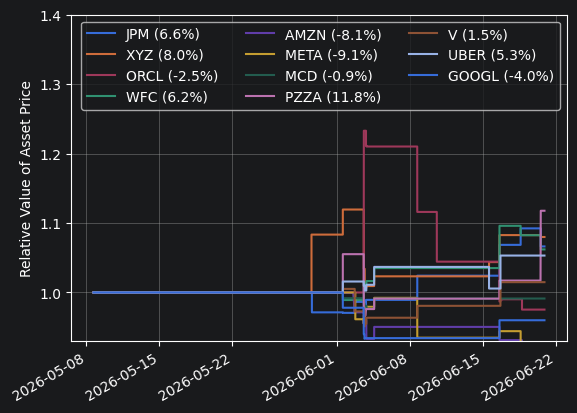

In [38]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [39]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-06-20 12:22:07+00:00    1.079879
2026-06-20 12:22:21+00:00    1.079879
2026-06-20 12:22:38+00:00    1.079879
2026-06-20 12:22:51+00:00    1.079879
2026-06-20 20:54:15+00:00    1.079879
Name: XYZ, Length: 356, dtype: float64

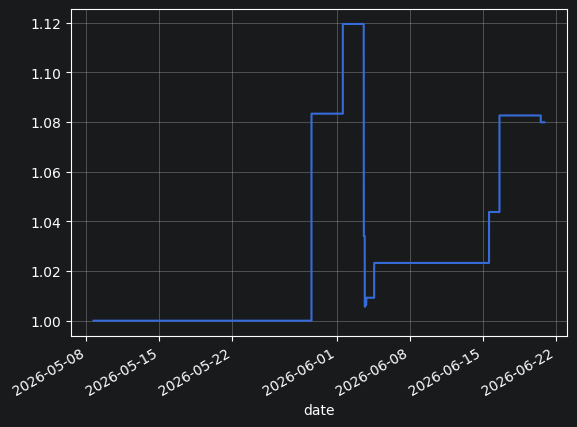

In [40]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [41]:
(data[data['trans_type'] == 'Stock Dividends']
 .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status', 'trans_type', 'net_amount'])
 )

,date,amount,asset_type,notes
32,2026-06-18 16:29:52+00:00,0.04,GM,$0.04 Dividend from General Motors
46,2026-06-18 04:00:00+00:00,0.07,HD,$0.07 Dividend from Home Depot
108,2026-06-16 04:00:00+00:00,0.20,MCD,$0.20 Dividend from McDonald's
126,2026-06-15 04:00:00+00:00,0.02,GOOG,$0.02 Dividend from Alphabet Inc. Class C
127,2026-06-15 04:00:00+00:00,0.02,GOOGL,$0.02 Dividend from Alphabet Inc. Class A
130,2026-06-12 04:00:00+00:00,0.05,DOW,$0.05 Dividend from Dow
383,2026-06-03 04:00:00+00:00,0.03,VMBS,$0.03 Dividend from Vanguard Mortgage-Backed S...


In [42]:
vanguard_data = (
    data[
        data['notes']
        .str.lower()
        .str.contains('vanguard')
    ]
    [['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data.sample(10, random_state=0xCAFE)


,date,net_amount,asset_price,notes,asset_type
284,2026-06-03 15:10:50+00:00,-10.0,48.06,$10 Purchase of Vanguard Total International B...,BNDX
421,2026-06-01 13:30:23+00:00,-25.0,95.08,$25 Purchase of Vanguard Real Estate ETF,VNQ
122,2026-06-15 13:30:12+00:00,-10.0,231.00,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
98,2026-06-16 13:30:03+00:00,-5.0,155.47,$5 Purchase of Energy ETF Vanguard,VDE
42,2026-06-18 14:09:00+00:00,-5.0,687.48,$5 Purchase of Vanguard S&P 500 ETF,VOO
338,2026-06-03 13:30:10+00:00,-1.0,164.64,$1 Purchase of Energy ETF Vanguard,VDE
442,2026-06-01 13:30:10+00:00,-10.0,397.97,$10 Purchase of Vanguard Consumer Discretionar...,VCR
29,2026-06-18 17:09:36+00:00,10.0,96.10,$10 Sale of Vanguard Real Estate ETF,VNQ
65,2026-06-16 14:00:16+00:00,-10.0,693.44,$10 Purchase of Vanguard S&P 500 ETF,VOO
216,2026-06-03 19:35:58+00:00,-10.0,158.69,$10 Purchase of Vanguard FTSE All World ex US ...,VSS


In [43]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VFH     5
VMBS    5
VONV    4
VNQ     3
VOO     3
VDE     3
VHT     3
VSS     3
VONG    2
VTEB    2
VGLT    2
VDC     2
BNDX    2
VCR     2
BIV     1
VBR     1
Name: count, dtype: int64

In [44]:
vanguard_note_name = (
    vanguard_data['notes']
    .pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (
    vanguard_data
    .assign(name=vanguard_note_name)
    .drop(columns=['notes'])
)
vanguard_data_asset_names.sample(10, random_state=0xCAFE)

,date,net_amount,asset_price,asset_type,name
284,2026-06-03 15:10:50+00:00,-10.0,48.06,BNDX,Vanguard Total International Bond ETF
421,2026-06-01 13:30:23+00:00,-25.0,95.08,VNQ,Vanguard Real Estate ETF
122,2026-06-15 13:30:12+00:00,-10.0,231.00,VDC,Vanguard Consumer Staples Index Fund ETF
98,2026-06-16 13:30:03+00:00,-5.0,155.47,VDE,Energy ETF Vanguard
42,2026-06-18 14:09:00+00:00,-5.0,687.48,VOO,Vanguard S&P 500 ETF
338,2026-06-03 13:30:10+00:00,-1.0,164.64,VDE,Energy ETF Vanguard
442,2026-06-01 13:30:10+00:00,-10.0,397.97,VCR,Vanguard Consumer Discretionary ETF
29,2026-06-18 17:09:36+00:00,10.0,96.10,VNQ,NaN
65,2026-06-16 14:00:16+00:00,-10.0,693.44,VOO,Vanguard S&P 500 ETF
216,2026-06-03 19:35:58+00:00,-10.0,158.69,VSS,Vanguard FTSE All World ex US Small Cap ETF


In [45]:
vanguard_data_asset_names_trans_count = (
    vanguard_data_asset_names
    .groupby(['asset_type', 'name'])
    ['date']
    .count()
    .sort_values(ascending=False)
)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VFH         Vanguard Financials ETF                        5
VMBS        Vanguard Mortgage-Backed Securities ETF        4
VONV        Vanguard Russell 1000 Value ETF                4
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
VOO         Vanguard S&P 500 ETF                           3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
BNDX        Vanguard Total International Bond ETF          2
VCR         Vanguard Consumer Discretionary ETF            2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VGLT        Vanguard Long-Treasury ETF                     2
VNQ         Vanguard Real Estate ETF                       2
VONG        Vanguard Russell 1000 Growth ETF               2
VTEB        Vanguard Tax-Exempt Bond ETF                   2
BIV         Vanguard Intermediate Term Bond ETF            1
VBR         Small Cap Value E

In [46]:
vanguard_asset_price_time = asset_holding_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VFH,VMBS,VONV,VNQ,VOO,VDE,VHT,VSS,VONG,VTEB,VGLT,VDC,BNDX,VCR,BIV,VBR
date,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:06+00:00,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN
2026-06-01 13:30:11+00:00,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,NaN,NaN,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
vanguard_trans_count

asset_type
VFH     5
VMBS    5
VONV    4
VNQ     3
VOO     3
VDE     3
VHT     3
VSS     3
VONG    2
VTEB    2
VGLT    2
VDC     2
BNDX    2
VCR     2
BIV     1
VBR     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

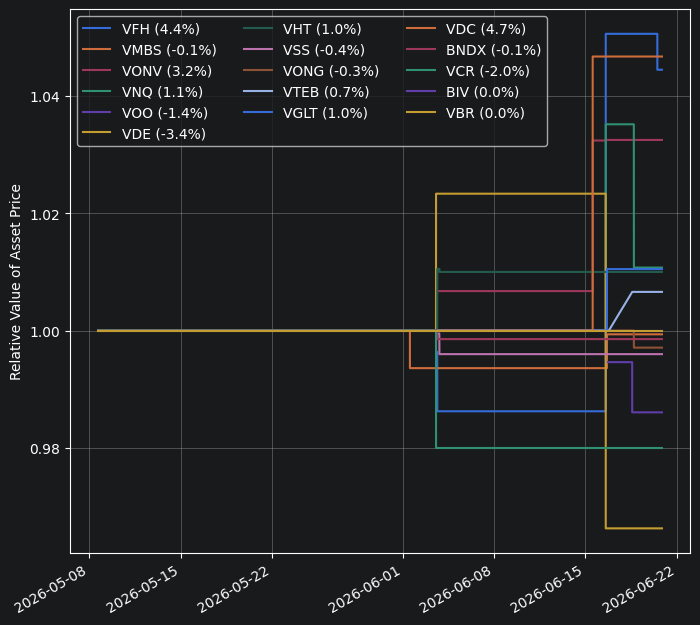

In [48]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
fig, ax = plt.subplots(figsize=(8, 8))

asset_price_rel_plot.plot.line(ax=ax)
plt.grid()
plt.legend(ncols=3, loc='upper left')
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')